### Phase 4.1 – Per-variable evaluation of latent predictions

In multi-output regression, global metrics such as MAE summarize performance but can hide systematic errors affecting only a subset of targets. Since the model predicts a latent vector (one value per latent dimension), it is necessary to compute the error separately for each latent variable.

In this phase, the Mean Absolute Error (MAE) is computed independently for each latent dimension on the test set. This provides a per-variable error profile that helps identify which latent components are consistently well predicted and which ones are harder due to noise, outliers, or model limitations. The resulting curves can be compared across architectures to detect unbalanced performance and potential biases in the latent space.


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


train_df = pd.read_csv("data_ready/train_dataset.csv")
val_df   = pd.read_csv("data_ready/val_dataset.csv")
test_df  = pd.read_csv("data_ready/test_dataset.csv")



# Strategy 1: y_0..y_31
label_cols = [c for c in train_df.columns if re.match(r"^Latent_\d+$", c)]
label_cols = sorted(label_cols, key=lambda x: int(x.split("_")[1]))  # Latent_0..Latent_31 in ordine

print("label_cols len:", len(label_cols))
print("label_cols first/last:", label_cols[:3], "...", label_cols[-3:])
assert len(label_cols) == 32, "Mi aspetto 32 dimensioni latenti (Latent_0..Latent_31)."


class WindowGenerator:
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df, label_columns,
                 batch_size=32):
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.label_columns = label_columns
        self.batch_size = batch_size

        self.label_col_indices = {name: i for i, name in enumerate(train_df.columns)}
        self.label_indices = np.array([self.label_col_indices[n] for n in label_columns], dtype=np.int32)

    def split_window(self, features):
        inputs = features[:, :self.input_width, :]
        labels = features[:, self.total_window_size - self.label_width:self.total_window_size, :]
        labels = tf.gather(labels, indices=self.label_indices, axis=-1)
        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=False,
            batch_size=self.batch_size
        )
        ds = ds.map(self.split_window)
        return ds

    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self):   return self.make_dataset(self.val_df)
    @property
    def test(self):  return self.make_dataset(self.test_df)


w10 = WindowGenerator(10, 1, 10, train_df, val_df, test_df, label_cols, batch_size=32)
w30 = WindowGenerator(30, 1, 10, train_df, val_df, test_df, label_cols, batch_size=32)


from tensorflow.keras import layers
from keras.saving import register_keras_serializable

@register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, input_width, d_model, **kwargs):
        super().__init__(**kwargs)
        self.input_width = input_width
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=input_width, output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=self.input_width, delta=1)
        pos = self.pos_emb(positions)
        return x + pos

    def get_config(self):
        config = super().get_config()
        config.update({"input_width": self.input_width, "d_model": self.d_model})
        return config

@register_keras_serializable()
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout = dropout

        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.mha(x, x, training=training)
        attn = self.drop1(attn, training=training)
        x = self.norm1(x + attn)

        ffn = self.ffn(x, training=training)
        ffn = self.drop2(ffn, training=training)
        x = self.norm2(x + ffn)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout
        })
        return config

CUSTOM_OBJECTS = {
    "PositionalEmbedding": PositionalEmbedding,
    "TransformerEncoderBlock": TransformerEncoderBlock
}


models_info = {
    "CNN1D_cfg1":     {"path": "saved_models/CNN1D_cfg1_w30_s10.keras",       "window": w30},
    "LSTM_w30_cfg1":  {"path": "saved_models/LSTM_w30_cfg1_w30_s10.keras",    "window": w30},
    "LSTM_w10_cfg1":  {"path": "saved_models/LSTM_w10_cfg1_w10_s10.keras",    "window": w10},
    "TR_w10_cfg2":    {"path": "saved_models/TR_w10_cfg2_w10_s10.keras",      "window": w10},
}


def predict_on_window(model, window_ds):
    y_true_list, y_pred_list = [], []

    for x_batch, y_batch in window_ds:
        y_pred = model.predict(x_batch, verbose=0)

        # y_pred: (B,32) -> (B,1,32)
        if y_pred.ndim == 2:
            y_pred = y_pred[:, None, :]

        # Safety: labels must not be empty
        if y_batch.shape[-1] == 0:
            raise ValueError("y_batch ha 0 colonne label: label_cols è errato o non combacia con il DF.")

        y_true_list.append(y_batch[:, 0, :])
        y_pred_list.append(y_pred[:, 0, :])

    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = np.concatenate(y_pred_list, axis=0)

    if y_true.shape[1] != y_pred.shape[1]:
        raise ValueError(f"Mismatch output dims: y_true={y_true.shape}, y_pred={y_pred.shape}")

    return y_true, y_pred


pred_cache = {}  

for name, info in models_info.items():
    print(f"Loading: {name}")
    model = tf.keras.models.load_model(info["path"], custom_objects=CUSTOM_OBJECTS)
    y_true, y_pred = predict_on_window(model, info["window"].test)
    pred_cache[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "err": (y_pred - y_true)
    }

print("Done. Cached models:", list(pred_cache.keys()))


label_cols len: 32
label_cols first/last: ['Latent_0', 'Latent_1', 'Latent_2'] ... ['Latent_29', 'Latent_30', 'Latent_31']
Loading: CNN1D_cfg1
Loading: LSTM_w30_cfg1
Loading: LSTM_w10_cfg1
Loading: TR_w10_cfg2


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Li


Done. Cached models: ['CNN1D_cfg1', 'LSTM_w30_cfg1', 'LSTM_w10_cfg1', 'TR_w10_cfg2']


## 4.1 — Metriche per variabile (valutazione per dimensione latente)

Il modello predice un vettore latente di dimensione 32 che rappresenta lo stato futuro del sistema.
Una metrica globale, come la MAE calcolata su tutte le dimensioni, fornisce solo una misura media dell’errore
e può nascondere comportamenti molto diversi tra le singole componenti del vettore latente.

Per soddisfare la richiesta “Evaluate metrics and variables separately”, in questa fase analizziamo l’errore
per ciascuna dimensione latente separatamente.

In particolare, per ogni modello calcoliamo la Mean Absolute Error (MAE) per ogni dimensione latente j:

MAE_j = E[ |ŷ_j − y_j| ]

Questa analisi permette di:
- identificare quali dimensioni latenti sono più facili da predire
- i


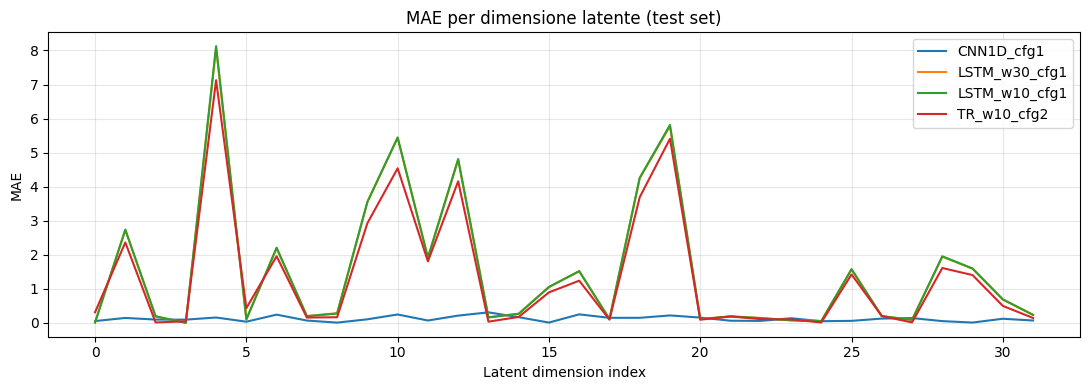

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "eval_figs"
os.makedirs(OUTDIR, exist_ok=True)

model_names = list(pred_cache.keys())
latent_dim = pred_cache[model_names[0]]["y_true"].shape[1]
dims = np.arange(latent_dim)

mae_per_dim = {}

for name in model_names:
    err = pred_cache[name]["err"]
    mae_per_dim[name] = np.mean(np.abs(err), axis=0)

plt.figure(figsize=(11, 4))
for name in model_names:
    plt.plot(dims, mae_per_dim[name], label=name)

plt.xlabel("Latent dimension index")
plt.ylabel("MAE")
plt.title("MAE per dimensione latente (test set)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "4_1_mae_per_dim_compare.png"), dpi=300)
plt.show()


## 4.2 — Distribuzione dell’errore (bias e outlier)

Nella Fase 4.1 abbiamo analizzato l’errore medio per ciascuna dimensione latente.
Tuttavia, una metrica media non fornisce informazioni sulla forma della distribuzione dell’errore.
Due modelli possono avere valori di MAE simili ma comportamenti molto diversi in termini di stabilità,
bias e presenza di outlier.

In questa fase analizziamo quindi la distribuzione dell’errore definito come:

errore = y_pred − y_true

Per ogni modello consideriamo:
- la distribuzione globale dell’errore, aggregata su tutte le dimensioni latenti
- la media dell’errore (bias), per valutare eventuali sovrastime o sottostime sistematiche
- la distribuzione dell’errore per singola dimensione latente

Questa analisi permette di capire se l’errore è:
- centrato intorno a zero
- asimmetrico
- dominato da pochi errori di grande ampiezza


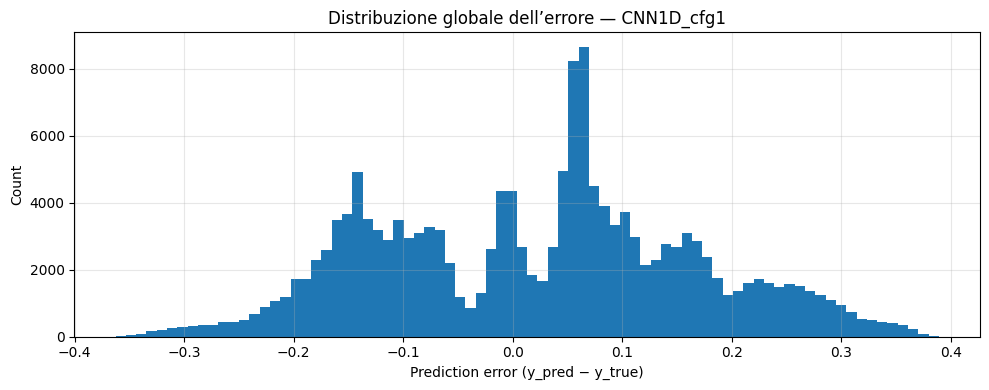

CNN1D_cfg1 — bias: 0.0212, std: 0.1444


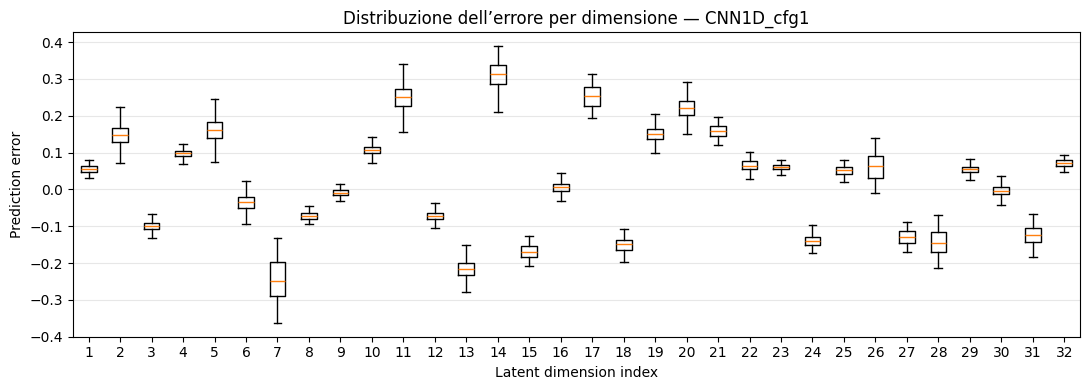

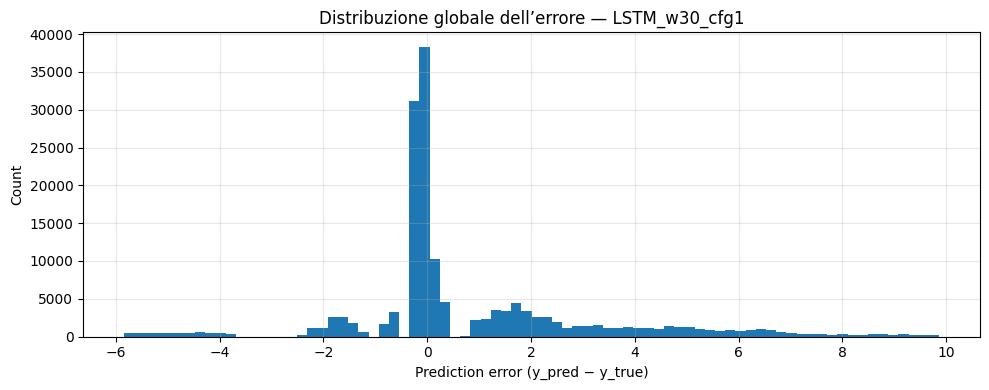

LSTM_w30_cfg1 — bias: 0.8714, std: 2.4355


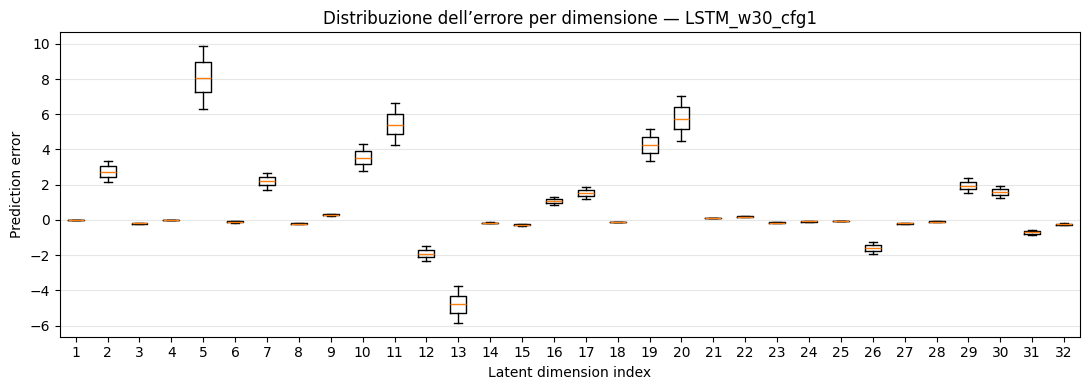

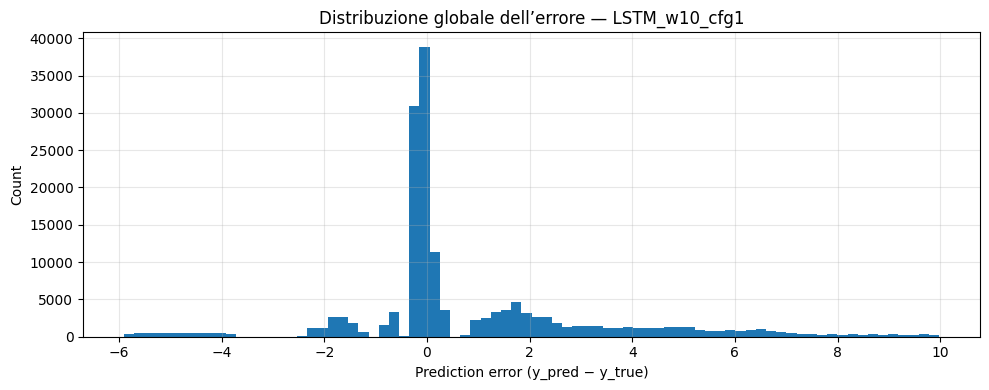

LSTM_w10_cfg1 — bias: 0.8753, std: 2.4469


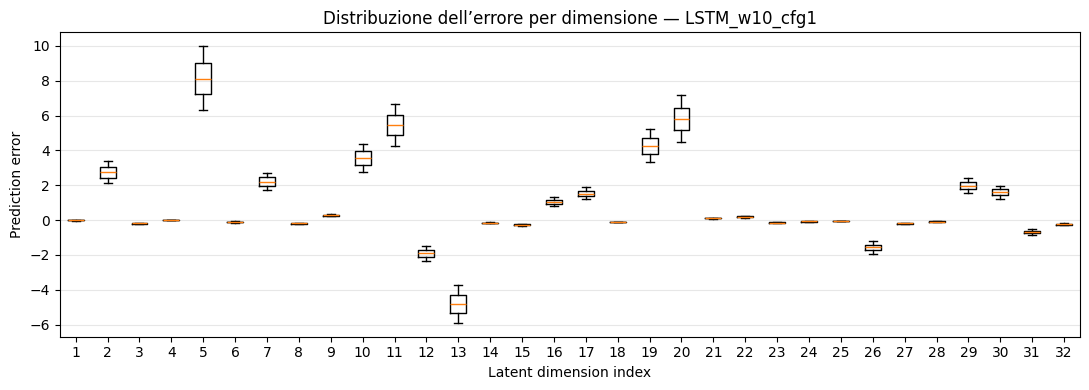

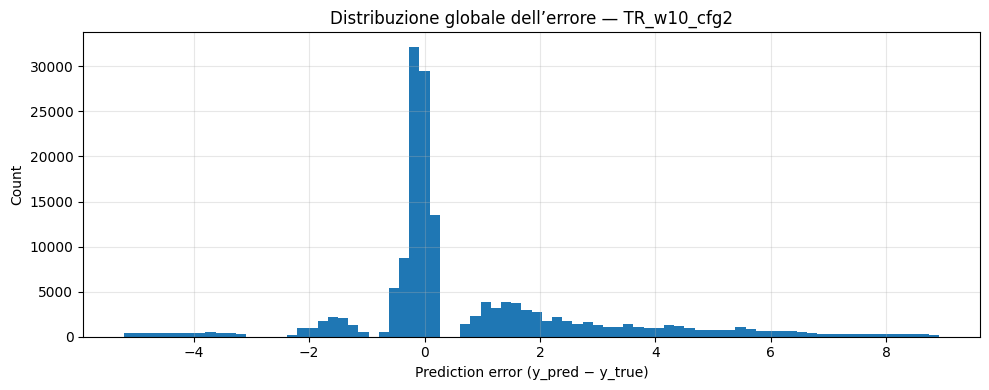

TR_w10_cfg2 — bias: 0.7499, std: 2.1497


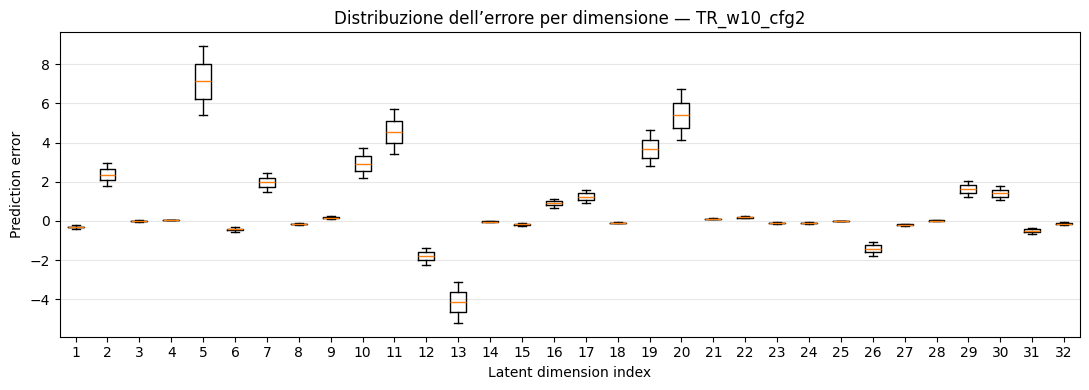

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "eval_figs"
os.makedirs(OUTDIR, exist_ok=True)

for name, data in pred_cache.items():
    err = data["err"]  

    err_flat = err.reshape(-1)

    bias = np.mean(err_flat)
    std = np.std(err_flat)

    plt.figure(figsize=(10, 4))
    plt.hist(err_flat, bins=80)
    plt.xlabel("Prediction error (y_pred − y_true)")
    plt.ylabel("Count")
    plt.title(f"Distribuzione globale dell’errore — {name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"4_2_err_hist_global_{name}.png"), dpi=300)
    plt.show()

    print(f"{name} — bias: {bias:.4f}, std: {std:.4f}")

    plt.figure(figsize=(11, 4))
    plt.boxplot(err, showfliers=False)
    plt.xlabel("Latent dimension index")
    plt.ylabel("Prediction error")
    plt.title(f"Distribuzione dell’errore per dimensione — {name}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"4_2_err_boxplot_{name}.png"), dpi=300)
    plt.show()


## 4.4 — Confronto finale tra modelli

Dopo aver analizzato separatamente l’errore per dimensione latente (Fase 4.1),
la distribuzione dell’errore (Fase 4.2) e il comportamento qualitativo delle predizioni
(Fase 4.3), in questa fase riassumiamo le prestazioni dei modelli tramite metriche globali.

L’obiettivo non è aggiungere nuove analisi, ma fornire una sintesi quantitativa
che permetta un confronto diretto tra le diverse architetture.

In particolare, consideriamo:
- la Mean Absolute Error (MAE) globale
- la Mean Squared Error (MSE) globale

Queste metriche sono calcolate aggregando l’errore su tutte le dimensioni latenti
e su tutti i campioni del test set.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

OUTDIR = "eval_figs"
os.makedirs(OUTDIR, exist_ok=True)

rows = []

for name, data in pred_cache.items():
    err = data["err"]
    mae_global = np.mean(np.abs(err))
    mse_global = np.mean(err**2)

    rows.append({
        "model": name,
        "MAE_global": mae_global,
        "MSE_global": mse_global
    })

metrics_df = pd.DataFrame(rows).sort_values("MAE_global")
metrics_df


,model,MAE_global,MSE_global
0,CNN1D_cfg1,0.122062,0.021288
3,TR_w10_cfg2,1.356377,5.183513
1,LSTM_w30_cfg1,1.549145,6.690877
2,LSTM_w10_cfg1,1.553927,6.753617


## 4.4 — Confronto finale tra modelli (metriche globali)

In questa sezione riassumiamo le prestazioni complessive dei modelli sul test set tramite:
- MAE_global: errore medio assoluto aggregato su tutte le dimensioni latenti e su tutti i campioni
- MSE_global: errore quadratico medio, più sensibile a errori di grande ampiezza

Queste metriche permettono un confronto diretto tra modelli, evidenziando sia accuratezza media (MAE)
sia stabilità rispetto agli outlier (MSE).


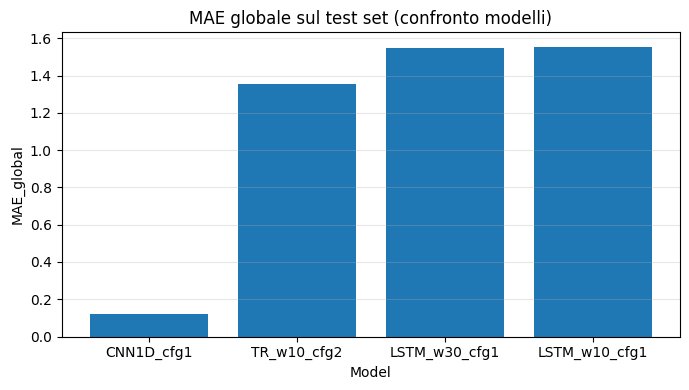

In [18]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["model"], metrics_df["MAE_global"])
plt.xlabel("Model")
plt.ylabel("MAE_global")
plt.title("MAE globale sul test set (confronto modelli)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "4_4_mae_global.png"), dpi=300)
plt.show()


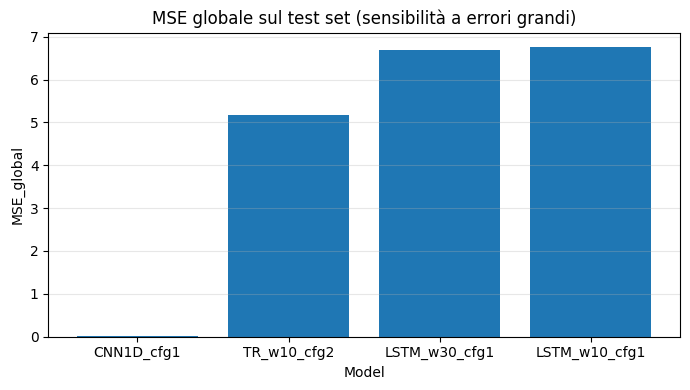

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["model"], metrics_df["MSE_global"])
plt.xlabel("Model")
plt.ylabel("MSE_global")
plt.title("MSE globale sul test set (sensibilità a errori grandi)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "4_4_mse_global.png"), dpi=300)
plt.show()
